# WAXS Integration script

In [15]:
import pyFAI
import numpy as np
import pandas as pd
import h5py
import fabio
import matplotlib.pyplot as plt
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator;

In [18]:
# parameters
sample = 'NPL14B'
run = 172

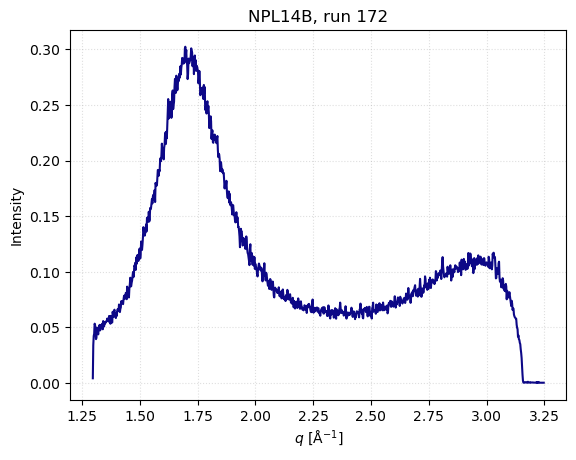

In [19]:
# load geometry (made with pyfai on Lab6)
ai = pyFAI.load("/asap3/petra3/gpfs/p10/2026/data/11023455/shared/online_analysis/LaB6_2026-05-14.poni");

# load data
det = 'e500'
samplerun = f'{sample}_{"%05d" % run}'
path = f'/asap3/petra3/gpfs/p10/2026/data/11023455/raw/{samplerun}/{det}/{samplerun}_master.h5'
f = h5py.File(path)
data=np.array(f['entry']['data']['data_000001']) 

# integrate and plot
plotting_offset = 0.02
n = 1
plt.figure()
integrated = []

#cmap = plt.get_cmap("plasma")
#colors = [cmap(i) for i in np.linspace(0, 1, 10)]

for f in range(1):
    mean_ = np.mean(data[n:n+9], axis = 0)
    mean_ = np.where(mean_<10, mean_, np.nan) # Remove broken pixels with infinite values
    i = ai.integrate1d(mean_, 1000, mask = None, unit = 'q_A^-1') # This line does the integration.
    plt.plot(i[0], i[1]-plotting_offset*f, color = colors[f], label = f'{n}-{n+99}')

    #n+=100

#plt.legend(ncol=2)
plt.grid(ls = ':', alpha = 0.4, which = 'both')
plt.xlabel('$q$ [Å$^{-1}$]')
plt.ylabel('Intensity')
plt.title(f'{sample}, run {run}')
plt.tight_layout;